In [1]:
import os
import random
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import GroupKFold, GridSearchCV, cross_val_predict

from sklearn.linear_model import LinearRegression, Ridge
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import clone

In [2]:
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

In [4]:
class ActivityClassifier:

    def __init__(self, dataset, outer_splits):

        self.dataset = dataset.dropna(subset=["vo2_mean"]).copy()

        self.outer_splits = outer_splits

        self.HR_FEATURES = [
            "zephyr_std",
            "zephyr_mean",
            "HRR_percent",
            "hrv_mean",
            "hrv_std"
        ]

        self.IMU_FEATURES = [
            "acc_mag__maximum",
            "acc_mag__variance",
            "gyro_mag__mean",
            "gyro_mag__variance"
        ]

        self.RESP_FEATURES = [
            "br_mean",
            "br_std",
            "br_amp_mean",
            "br_amp_std",
            "ventilation_proxy"
        ]

        self.DEMO_FEATURES = [
            #"BMI",
            "Age",
            "Weight",
            "Height",
            "Gender"
        ]

        self.FEATURE_SETS = {
            "HR_IMU": self.HR_FEATURES + self.IMU_FEATURES,

            "HR_IMU_RESP":
                self.HR_FEATURES +
                self.IMU_FEATURES +
                self.RESP_FEATURES,

            "IMU_RESP":
                self.IMU_FEATURES +
                self.RESP_FEATURES,

            "ALL_without_HR":
                self.IMU_FEATURES +
                self.RESP_FEATURES +
                self.DEMO_FEATURES,

            "ALL":
                self.HR_FEATURES +
                self.IMU_FEATURES +
                self.RESP_FEATURES +
                self.DEMO_FEATURES
        }


        # Random Forest activity classifier grid

        self.PARAM_GRID = {
            "model__n_estimators": [100, 200, 300],
            "model__max_depth": [5, 10, None],
            "model__min_samples_leaf": [1, 2, 5]
        }

        self.predictions = {}

        self.tuning_results = []

    
    def run(self):

        X_all = self.dataset
        y_activity = self.dataset["activity"]
        groups = self.dataset["participant"]

        for feature_name, features in self.FEATURE_SETS.items():

            print(
                f"\n===== Activity classification: "
                f"{feature_name} ====="
            )

            X = X_all[features]

            # OUTER LOSO
            for fold, (train_idx, test_idx) in enumerate(
                            self.outer_splits
                        ):

                X_train = X.iloc[train_idx]
                X_test = X.iloc[test_idx]

                y_train = y_activity.iloc[train_idx]
                y_test = y_activity.iloc[test_idx]

                groups_train = groups.iloc[train_idx]

                test_participant = groups.iloc[test_idx].iloc[0]

                
                # Encode activity
                encoder = LabelEncoder()

                y_train_encoded = encoder.fit_transform(
                    y_train
                )

                y_test_encoded = encoder.transform(
                    y_test
                )

               
                # Activity classifier pipeline

                pipeline = Pipeline([
                    (
                        "scaler",
                        StandardScaler()
                    ),
                    (
                        "model",
                        RandomForestClassifier(
                            random_state=42,
                            n_jobs=1
                        )
                    )
                ])

                # INNER GROUP CV
                inner_cv = GroupKFold(
                    n_splits=4
                )

                search = GridSearchCV(
                    estimator=pipeline,
                    param_grid=self.PARAM_GRID,
                    scoring="accuracy",
                    cv=inner_cv,
                    n_jobs=-1,
                    refit=True
                )

                # Hyperparameter tuning
                search.fit(
                    X_train,
                    y_train_encoded,
                    groups=groups_train
                )

                best_model = search.best_estimator_

                pred_activity_train = (
                    best_model.predict(X_train)
                )

                pred_activity_test = (
                    best_model.predict(X_test)
                )


                key = (
                    feature_name,
                    fold
                )

                self.predictions[key] = {
                    "train_idx": train_idx,
                    "test_idx": test_idx,
                    "pred_train": pred_activity_train,
                    "pred_test": pred_activity_test
                }
                
                
                # Save tuning information
                self.tuning_results.append({
                    "Feature_Set": feature_name,
                    "Fold": fold,
                    "Test_Participant": test_participant,
                    "Best_Params": search.best_params_,
                    "Best_Inner_Accuracy":
                        search.best_score_
                })

        return self.predictions

In [123]:
class LOSOExperiment:

    def __init__(self, dataset, outer_splits, activity_predictions):

        self.dataset = dataset.dropna(subset=["vo2_mean"]).copy()
        self.outer_splits = outer_splits
        self.activity_predictions = activity_predictions

        self.results_summary = []
        self.results_detailed = {}
        self.feature_importances = {}
        self.tuning_results = []

        self.shap_storage = {}
        self.lime_storage = {}

        # Feature groups
         # Define feature groups
        self.HR_FEATURES = ["zephyr_std", "zephyr_mean", "HRR_percent", "hrv_mean", "hrv_std","hr_slope"]
        
        self.IMU_FEATURES = [
            # "acc_mag__mean",
            # "acc_mag__standard_deviation",
             "acc_mag__maximum",
            "acc_mag__variance",
            # "acc_mag__minimum",
            "gyro_mag__mean",
            #"gyro_mag__standard_deviation",
            # "gyro_mag__maximum",
            # "gyro_mag__minimum"
            "gyro_mag__variance",

            # "acc_mag__root_mean_square",
            #'acc_energy__mean',
            #'gyro_energy__mean',

        ]

        self.RESP_FEATURES = [
            "br_mean",
            #"br_std",
            "br_amp_mean",
            #"br_amp_std",
            "ventilation_proxy"
        ]

        self.DEMO_FEATURES = [
            #"BMI",
            "Age",
            "Weight",
            "Height",
            "Gender"
        ]

        self.FEATURE_SETS = {
            "HR_IMU": self.HR_FEATURES + self.IMU_FEATURES,
            "HR_IMU_RESP": self.HR_FEATURES + self.IMU_FEATURES + self.RESP_FEATURES,
            "ALL": self.HR_FEATURES + self.IMU_FEATURES + self.RESP_FEATURES+ self.DEMO_FEATURES,
            "IMU_RESP": self.IMU_FEATURES + self.RESP_FEATURES,
            "ALL_without_HR": self.IMU_FEATURES + self.RESP_FEATURES + self.DEMO_FEATURES,
        }


        self.PARAM_GRIDS = {
        
            "ridge": {
                "model__alpha": [0.01, 0.1, 1.0, 10.0, 50.0, 100.0,200.0, 500.0]
            },
        
            "random_forest": {
                "model__n_estimators": [100, 200, 300],
                "model__max_depth": [5, 10, None],
                "model__min_samples_leaf": [1, 2, 5]
            },
        
            "xgboost": {
                "model__n_estimators": [100, 150, 300],
                "model__max_depth": [2, 3, 5],
                "model__learning_rate": [0.05, 0.1],
                "model__subsample": [0.8, 1.0],
                "model__colsample_bytree": [0.8, 1.0]
            }
         }

    def run_loso(self, feature_columns, model, feature_set_name, model_type):

        X = self.dataset[feature_columns]
        y = self.dataset["vo2_mean"]
        groups = self.dataset["participant"]

        predictions_storage = {}
        fold_results = []

        for fold, (train_idx, test_idx) in enumerate(self.outer_splits):

            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
            groups_train = groups.iloc[train_idx]

            activity_train = self.dataset.iloc[train_idx]["activity"]
            activity_test = self.dataset.iloc[test_idx]["activity"]
            
            #Getting activity predictions
            activity_info = self.activity_predictions[
                (feature_set_name, fold)
            ]
            
            pred_activity_train = (
                activity_info["pred_train"]
            )
            
            pred_activity_test = (
                activity_info["pred_test"]
            )

            #Encode true activity
            activity_encoder = LabelEncoder()
            
            activity_train_enc = (
                activity_encoder.fit_transform(
                    activity_train
                )
            )
            
            activity_test_enc = (
                activity_encoder.transform(
                    activity_test
                )
            )
            
            #Base data
            X_train_base = X_train.copy()
            X_test_base = X_test.copy()

            #true activity
            X_train_true = X_train.copy()
            X_test_true = X_test.copy()
            
            X_train_true["true_activity"] = activity_train_enc
            X_test_true["true_activity"] = activity_test_enc
            
            X_train_true = pd.get_dummies(
                X_train_true,
                columns=["true_activity"]
            )
            
            X_test_true = pd.get_dummies(
                X_test_true,
                columns=["true_activity"]
            )
            
            X_train_true, X_test_true = X_train_true.align(
                X_test_true,
                join="left",
                axis=1,
                fill_value=0
            )

            #pred activity
            X_train_pred = X_train.copy()
            X_test_pred = X_test.copy()
            
            X_train_pred["pred_activity"] = pred_activity_train
            X_test_pred["pred_activity"] = pred_activity_test
            
            X_train_pred = pd.get_dummies(
                X_train_pred,
                columns=["pred_activity"]
            )
            
            X_test_pred = pd.get_dummies(
                X_test_pred,
                columns=["pred_activity"]
            )
            
            X_train_pred, X_test_pred = X_train_pred.align(
                X_test_pred,
                join="left",
                axis=1,
                fill_value=0
            )

            datasets = {
            
                feature_set_name:
                    (X_train_base, X_test_base),
            
                f"{feature_set_name}_TRUE_ACTIVITY":
                    (X_train_true, X_test_true),
            
                f"{feature_set_name}_PRED_ACTIVITY":
                    (X_train_pred, X_test_pred)
            }

            # print(datasets.keys())

            test_subject = groups.iloc[test_idx].unique()[0]
        
            from sklearn.base import clone

            for version, (Xtr,Xte) in datasets.items():
                # print("VERSION:", version)
                model_clone = clone(model)
                
                pipeline = Pipeline([
                    ("scaler", StandardScaler()),
                    ("model", model_clone)
                ])

                if model_type in self.PARAM_GRIDS:
                
                    inner_cv = GroupKFold(n_splits=4)
                    
                    search = GridSearchCV(
                        estimator=pipeline,
                        param_grid=self.PARAM_GRIDS[model_type],
                        scoring="neg_root_mean_squared_error",
                        cv=inner_cv,
                        n_jobs=-1,
                        refit=True
                    )
                    
                    search.fit(
                        Xtr,
                        y_train,
                        groups=groups_train
                    )
                    
                    pipeline = search.best_estimator_
                    
                    best_params = search.best_params_
                    best_inner_rmse = -search.best_score_
                    
                    self.tuning_results.append({
                        "Model": model_type,
                        "Feature_Set": version,
                        "Test_Participant": test_subject,
                        "Best_Params": best_params,
                        "Best_Inner_RMSE": best_inner_rmse
                    })
                
                else:
                
                    # Linear regression: no hyperparameter tuning
                    pipeline.fit(Xtr, y_train)
                    
                    self.tuning_results.append({
                        "Model": model_type,
                        "Feature_Set": version,
                        "Test_Participant": test_subject,
                        "Best_Params": "None",
                        "Best_Inner_RMSE": None
                    })
                
    
                scaler = pipeline.named_steps["scaler"]
                model_fitted = pipeline.named_steps["model"]
    
                X_train_scaled = scaler.transform(Xtr)
                X_test_scaled = scaler.transform(Xte)
    
                # SHAP computation
                shap_values = None
    
                if hasattr(model_fitted, "coef_"):
    
                    explainer = shap.LinearExplainer(model_fitted, X_train_scaled)
                    shap_values = explainer.shap_values(X_test_scaled)
                    X_eval_used = X_test_scaled
    
                elif hasattr(model_fitted, "feature_importances_"):
    
                    explainer = shap.TreeExplainer(model_fitted)
                    shap_values = explainer.shap_values(X_test_scaled)
                    X_eval_used = X_test_scaled
    
                else:  # MLP 
                
                    explainer = shap.Explainer(pipeline.predict, Xtr)
                    shap_values = explainer(Xte).values
                    X_eval_used = Xte
    
                if shap_values is not None:
    
                    if model_type not in self.shap_storage:
                        self.shap_storage[model_type] = {}
    
                    if version not in self.shap_storage[model_type]:
                        self.shap_storage[model_type][version] = {
                            "shap_values": [],
                            "X_eval": []
                        }
                    all_features = list(Xtr.columns)
                    
                    X_eval_df = pd.DataFrame(X_eval_used, columns=all_features)
                    X_eval_df["activity"] = self.dataset.iloc[test_idx]["activity"].values
    
                    self.shap_storage[model_type][version]["shap_values"].append(shap_values)
                    self.shap_storage[model_type][version]["X_eval"].append(X_eval_df)
    
                y_pred_train = pipeline.predict(Xtr)
                y_pred_test = pipeline.predict(Xte)
    
                #LIME STORAGE
                if model_type not in self.lime_storage:
                    self.lime_storage[model_type] = {}
                
                if version not in self.lime_storage[model_type]:
                    self.lime_storage[model_type][version] = []

                cols = list(Xtr.columns)
                
                predict_fn = (
                    lambda x,
                           cols=cols,
                           pipe=pipeline:
                    pipe.predict(
                        pd.DataFrame(x, columns=cols)
                    )
                )
                
                self.lime_storage[model_type][version].append({
                    "fold": test_subject,
                
                    "X_train": Xtr.values,
                    "X_test": Xte.values,
                    "columns": cols,
                    "predict_fn": predict_fn,
                    "features": list(Xtr.columns),
                
                    "y_true": y_test.values,
                    "y_pred": y_pred_test,
                    "activity": self.dataset.iloc[test_idx]["activity"].values
                })

                version_predictions = []
    
                for i in range(len(y_test)):
                    version_predictions.append({
                        "Feature_Set": version,
                        "participant": test_subject,
                        "activity": self.dataset.iloc[test_idx]["activity"].values[i],
                        "y_true": y_test.iloc[i],
                        "y_pred": y_pred_test[i]
                })

                version_pred_df = pd.DataFrame(version_predictions)
                
                if version not in predictions_storage:
                    predictions_storage[version] = []
                
                predictions_storage[version].append(version_pred_df)              
    
                fold_results.append({
                    "Feature_Set": version,
                    "participant": test_subject,
                    "Train_R2": r2_score(y_train, y_pred_train),
                    "Test_R2": r2_score(y_test, y_pred_test),
                    "MAE": mean_absolute_error(y_test, y_pred_test),
                    "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_test)),
                })

        results_df = pd.DataFrame(fold_results)

        # print(results_df["Feature_Set"].unique())

        summary_df = (
            results_df
            .groupby("Feature_Set")
            .agg({
                "Train_R2":"mean",
                "Test_R2":["mean","std"],
                "MAE":"mean",
                "RMSE":"mean"
            })
        )

        summary_df.columns = [
            "Mean_Train_R2",
            "Mean_Test_R2",
            "Std_Test_R2",
            "Mean_MAE",
            "Mean_RMSE"
        ]
        
        summary_df = summary_df.reset_index()

        for version in predictions_storage:
        
            predictions_storage[version] = pd.concat(
                predictions_storage[version]
            ).reset_index(drop=True)

        return results_df, summary_df, predictions_storage

    
    def run_all(self, model_type="linear"):

        if model_type == "linear":
            model = LinearRegression()

        elif model_type == "ridge":
            model = Ridge()

        elif model_type == "xgboost":
            model = XGBRegressor(
                random_state=42,
                objective="reg:squarederror",
                n_jobs= 1
            )

        elif model_type == "random_forest":
            model = RandomForestRegressor(
                random_state=42,
                n_jobs = 1
        )

        else:
            raise ValueError("Unsupported model")


        fold_results_all = []

        for name, features in self.FEATURE_SETS.items():

            print(f"Running {model_type} | {name}")

            results_df, summary, predictions_storage = self.run_loso(
                features,
                model,
                name,
                model_type
            )

            # Store fold-level results
            results_df["Model"] = model_type
            fold_results_all.append(results_df)
            
            if "predictions" not in self.results_detailed:
                self.results_detailed["predictions"] = {}

            self.results_detailed["predictions"].update(predictions_storage)


            self.results_summary.extend(
                summary.to_dict("records")
            )
            # print(type(self.results_summary[0]))

        return (
            pd.concat(fold_results_all, ignore_index=True),
            pd.DataFrame(self.results_summary)
        )

    def get_shap_data(self, model_type, feature_set):

        data = self.shap_storage[model_type][feature_set]

        shap_values = np.vstack(data["shap_values"])
        X_all = pd.concat(data["X_eval"]).reset_index(drop=True)

        return shap_values, X_all

In [96]:
class SHAPVisualizer:

    def __init__(self, shap_values, X):
        self.shap_values = shap_values
        self.X = X

    def summary(
        self,
        max_display=15,
        figsize=(8, 6),
        save_path=None
    ):

        X_features = self.X.drop(
            columns=["activity"],
            errors="ignore"
        )

        # plt.figure(figsize=figsize)

        shap.summary_plot(
            self.shap_values,
            X_features,
            max_display=max_display,
            plot_size=figsize,
            show=False
        )

        ax = plt.gca()

        # X-axis
        ax.set_xlabel(
            "SHAP value (impact on model output)",
            fontsize=14,
            fontweight="bold"
        )
    
        # X-axis tick labels
        ax.tick_params(
            axis="x",
            labelsize=15
        )
    
        # Feature names
        for label in ax.get_yticklabels():
            label.set_fontsize(16)
            label.set_fontweight("bold")
    
        # X tick labels bold
        for label in ax.get_xticklabels():
            label.set_fontweight("bold")

        plt.tight_layout()

        if save_path is not None:
            plt.savefig(
                save_path,
                dpi=300,
                bbox_inches="tight"
            )

        plt.show()

In [136]:
class LIMEAnalyzer:

    def __init__(self, experiment):
        self.exp = experiment

    #aggregate onehotencoding of activity
    def aggregate_activity_features(self, obj):

        true_rows = [
            r for r in obj.index
            if str(r).startswith("true_activity_")
        ]
    
        pred_rows = [
            r for r in obj.index
            if str(r).startswith("pred_activity_")
        ]
    
        if len(true_rows):
            obj.loc["TRUE_ACTIVITY"] = (
                obj.loc[true_rows].sum(axis=0)
            )
            obj = obj.drop(true_rows)
    
        if len(pred_rows):
            obj.loc["PRED_ACTIVITY"] = (
                obj.loc[pred_rows].sum(axis=0)
            )
            obj = obj.drop(pred_rows)
    
        return obj
    
    #Lime global importance plot
    def plot_global_importance(
        self,
        model_type,
        version,
        top_n=15,
        save_path = None
    ):

        rows = []
    
        items = self.exp.lime_storage[model_type][version]
    
        for item in items:
    
            explainer = LimeTabularExplainer(
                item["X_train"],
                feature_names=item["features"],
                mode="regression"
            )
    
            for i in range(len(item["X_test"])):
    
                exp = explainer.explain_instance(
                    item["X_test"][i],
                    item["predict_fn"]
                )
    
                for f, w in exp.as_list():
    
                    for feat in item["features"]:
    
                        if feat in f:
    
                            rows.append(
                                (feat, abs(w))
                            )
    
        df = pd.DataFrame(
            rows,
            columns=["feature", "importance"]
        )
    
        imp = (
            df.groupby("feature")["importance"]
            .mean()
            .sort_values(ascending=False)
        )

        imp = self.aggregate_activity_features(imp)

        #plot
        fig, ax = plt.subplots(figsize=(8, 7))
    
        imp.head(top_n).sort_values().plot.barh(ax=ax)
    
        plt.xlabel("Importance")

        ax.set_xlabel(
            "Importance",
            fontsize=16
        )
    
        ax.set_ylabel(
            "Feature",
            fontsize=16
        )
    
    
        ax.tick_params(
            axis="both",
            labelsize=16
        )
    
        plt.tight_layout()
    
        if save_path is not None:
            plt.savefig(
                save_path,
                dpi=300,
                bbox_inches="tight"
            )
    
        plt.show()


    #Lime activity heatmap
    def plot_activity_heatmap(
        self,
        model_type,
        version,
        top_n=10,
        save_path=None
    ):
    
        rows = []
    
        items = self.exp.lime_storage[model_type][version]
    
        for item in items:
    
            explainer = LimeTabularExplainer(
                item["X_train"],
                feature_names=item["features"],
                mode="regression"
            )
    
            for i in range(len(item["X_test"])):
    
                activity = item["activity"][i]
    
                exp = explainer.explain_instance(
                    item["X_test"][i],
                    item["predict_fn"]
                )
    
                for f, w in exp.as_list():
    
                    for feat in item["features"]:
    
                        if feat in f:
    
                            rows.append({
                                "activity": activity,
                                "feature": feat,
                                "importance": abs(w)
                            })
    
        df = pd.DataFrame(rows)
    

        # Create activity × feature matrix      
        pivot = (
            df.groupby(
                ["feature", "activity"]
            )["importance"]
            .mean()
            .unstack()
        )
        
        # Aggregate activity one-hot features        
        pivot = self.aggregate_activity_features(
            pivot
        )    
 
        # Find globally important features AFTER aggregation
        
        mean_importance = (
            pivot.mean(axis=1)
            .sort_values(ascending=False)
        )
        
        top_features = (
            mean_importance
            .head(top_n)
            .index
        )
        
        pivot = pivot.loc[top_features]
    
        fig, ax = plt.subplots(figsize=(10, 8))

        sns.heatmap(
            pivot,
            annot=True,
            cmap="viridis",
            ax=ax,
            annot_kws={"fontsize": 16}
        )
    
        ax.set_title(
            f"LIME Importance Across Activities\n{version}",
            fontsize=16
        )
    
        ax.set_xlabel(
            "Activity",
            fontsize=16
        )
    
        ax.set_ylabel(
            "Feature",
            fontsize=16
        )
    
        ax.tick_params(
            axis="y",
            labelsize=16
        )

        plt.setp(
            ax.get_xticklabels(),
            rotation=45,
            ha="right",
            fontsize=16
        )
        
    
        plt.tight_layout()
    
        if save_path is not None:
            plt.savefig(
                save_path,
                dpi=300,
                bbox_inches="tight"
            )
    
        plt.show()


    #Activity wise LIME Standard deviation

    def plot_activity_sd_heatmap(
        self,
        model_type,
        version,
        top_n=10,
        save_path=None
    ):
    
        rows = []
    
        items = self.exp.lime_storage[model_type][version]
    
        for item in items:
    
            explainer = LimeTabularExplainer(
                item["X_train"],
                feature_names=item["features"],
                mode="regression"
            )
    
            for i in range(len(item["X_test"])):
    
                activity = item["activity"][i]
    
                exp = explainer.explain_instance(
                    item["X_test"][i],
                    item["predict_fn"]
                )
    
                for f, w in exp.as_list():
    
                    for feat in item["features"]:
    
                        if feat in f:
    
                            rows.append({
                                "activity": activity,
                                "feature": feat,
                                "importance": abs(w)
                            })
    
        df = pd.DataFrame(rows)
    

        # Create activity × feature matrix
        pivot = (
            df.groupby(
                ["feature", "activity"]
            )["importance"]
            .std()
            .unstack()
        )
        
        

        # Aggregate activity one-hot features
        pivot = self.aggregate_activity_features(
            pivot
        )
        

        # Find globally important features AFTER aggregation
        mean_importance = (
            pivot.mean(axis=1)
            .sort_values(ascending=False)
        )
        
        top_features = (
            mean_importance
            .head(top_n)
            .index
        )
        
        pivot = pivot.loc[top_features]
    
        fig, ax = plt.subplots(figsize=(10, 8))

        sns.heatmap(
            pivot,
            annot=True,
            cmap="viridis",
            ax=ax,
            annot_kws={"fontsize": 16}
        )
    
        ax.set_title(
            f"LIME Importance Across Activities\n{version}",
            fontsize=16
        )
    
        ax.set_xlabel(
            "Activity",
            fontsize=16
        )
    
        ax.set_ylabel(
            "Feature",
            fontsize=16
        )
    
        ax.tick_params(
            axis="y",
            labelsize=16
        )

        plt.setp(
            ax.get_xticklabels(),
            rotation=45,
            ha="right",
            fontsize=16
        )

    
        plt.tight_layout()
    
        if save_path is not None:
            plt.savefig(
                save_path,
                dpi=300,
                bbox_inches="tight"
            )
    
        plt.show()
    


    # Explain single sample
    def explain_sample(self, model_type, feature_set, fold_idx=0, sample_idx=0):

        items = self.exp.lime_storage[model_type][feature_set]
        item = items[fold_idx]

        explainer = LimeTabularExplainer(
            item["X_train"],
            feature_names=item["features"],
            mode="regression"
        )

        exp = explainer.explain_instance(
            item["X_test"][sample_idx],
            item["predict_fn"]
        )

        print(
            f"Participant: {item['fold']}, "
            f"Activity: {item['activity'][sample_idx]}, "
            f"Error: {abs(item['y_true'][sample_idx] - item['y_pred'][sample_idx]):.2f}"
        )

        exp.as_pyplot_figure()
        plt.title(f"{model_type} | {feature_set} | Fold {item['fold']}")
        plt.show()

        return exp

    # Worst predictions
    def explain_bad_predictions(self, model_type, feature_set, top_n=5):

        results = []
        items = self.exp.lime_storage[model_type][feature_set]

        for item in items:

            errors = abs(item["y_true"] - item["y_pred"])

            for i, e in enumerate(errors):
                results.append((e, item, i))

        results = sorted(results, key=lambda x: x[0], reverse=True)

        for err, item, idx in results[:top_n]:

            print(
                f"\nError: {err:.3f} | Fold: {item['fold']} | "
                f"Activity: {item['activity'][idx]}"
            )

            explainer = LimeTabularExplainer(
                item["X_train"],
                feature_names=item["features"],
                mode="regression"
            )

            exp = explainer.explain_instance(
                item["X_test"][idx],
                item["predict_fn"]
            )

            exp.as_pyplot_figure()
            plt.show()

  

In [ ]:
# Activity

In [132]:
PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "Results"

dataset = pd.read_csv(DATA_DIR / "window_30s_dataset.csv")

logo = LeaveOneGroupOut()

outer_splits = list(
    logo.split(
        dataset,
        dataset["vo2_mean"],
        dataset["participant"]
    )
)

activity_classifier = ActivityClassifier(
    dataset,
    outer_splits
)

activity_predictions = (
    activity_classifier.run()
)


===== Activity classification: HR_only =====


python(26827) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(26828) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(26829) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(26830) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(26831) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(26832) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.



===== Activity classification: IMU_only =====

===== Activity classification: HR_IMU =====

===== Activity classification: HR_IMU_RESP =====

===== Activity classification: IMU_RESP =====

===== Activity classification: ALL_without_HR =====

===== Activity classification: ALL =====


In [ ]:
models = ["linear" ,"ridge","xgboost", "random_forest" ]
all_fold_results = []
all_results = []
experiments = {}

for model in models:

    print(f"\n===== Running {model} =====")

    exp = LOSOExperiment(filtered_dataset, outer_splits, activity_predictions)
    fold_results, results = exp.run_all(model_type=model)
    results["Model"] = model
    all_results.append(results)
    all_fold_results.append(fold_results)
    experiments[model] = exp

In [ ]:
final_results = pd.concat(all_results, ignore_index=True)

In [56]:
final_results.sort_values("Mean_Test_R2", ascending=False)

,Feature_Set,Mean_Train_R2,Mean_Test_R2,Std_Test_R2,Mean_MAE,Mean_RMSE,Model
46,HR_IMU_PRED_ACTIVITY,0.976294,0.772934,0.167622,0.501535,0.745068,random_forest
45,HR_IMU,0.973525,0.770235,0.173892,0.502239,0.740562,random_forest
47,HR_IMU_TRUE_ACTIVITY,0.976096,0.764692,0.171035,0.507771,0.755676,random_forest
32,HR_IMU_TRUE_ACTIVITY,0.958631,0.743228,0.203130,0.533820,0.754614,xgboost
31,HR_IMU_PRED_ACTIVITY,0.961013,0.742526,0.212753,0.527861,0.759612,xgboost
30,HR_IMU,0.968469,0.731560,0.224525,0.540322,0.774947,xgboost
48,HR_IMU_RESP,0.975288,0.731224,0.212867,0.544814,0.796663,random_forest
49,HR_IMU_RESP_PRED_ACTIVITY,0.979655,0.730278,0.209221,0.548719,0.801453,random_forest
50,HR_IMU_RESP_TRUE_ACTIVITY,0.980969,0.721865,0.207706,0.547003,0.806496,random_forest
36,ALL,0.964492,0.712872,0.220257,0.569309,0.798437,xgboost


# To generate SHAP visualisations, select the desired experiment and retrieve the SHAP values and corresponding features using get_shap_data(). Initialise SHAPVisualizer with these values and use summary() to generate the global SHAP feature-importance plot.

/var/folders/bd/yl57j36x4dxgj75stpyspnvm0000gp/T/ipykernel_17956/2801187344.py:21: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


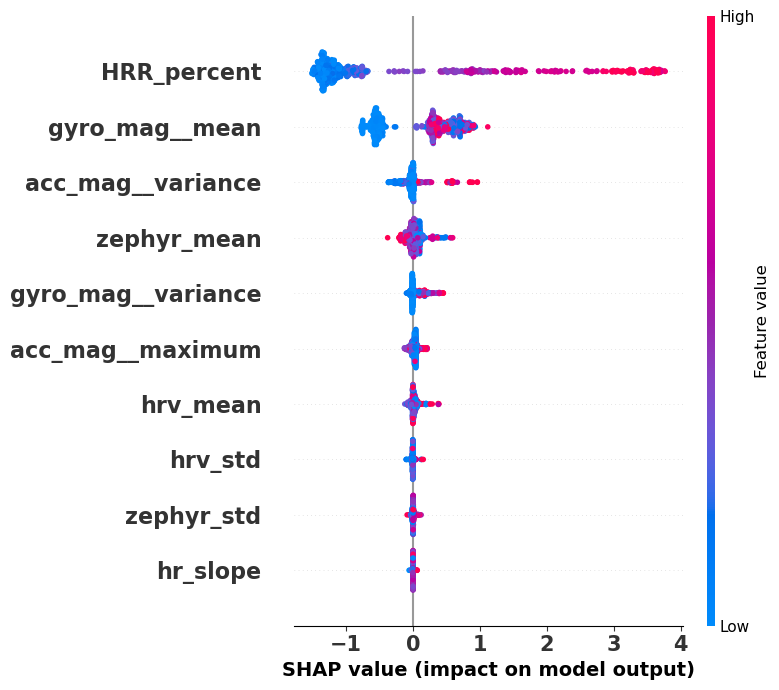

In [97]:
exp = experiments["random_forest"]

shap_values, X_all = exp.get_shap_data(
    model_type="random_forest",
    feature_set="HR_IMU"
)

viz = SHAPVisualizer(shap_values, X_all)

viz.summary(
    max_display=10,
    figsize=(8, 7),
    save_path="RF_HR_IMU_SHAP.png"
)

# To generate LIME visualisations, initialise LIMEAnalyzer with the selected experiment and specify the corresponding model_type and version. Use plot_global_importance() to obtain global feature importance, plot_activity_heatmap() to visualise mean feature importance across activities, and plot_activity_sd_heatmap() to visualise the standard deviation of feature importance across activities.

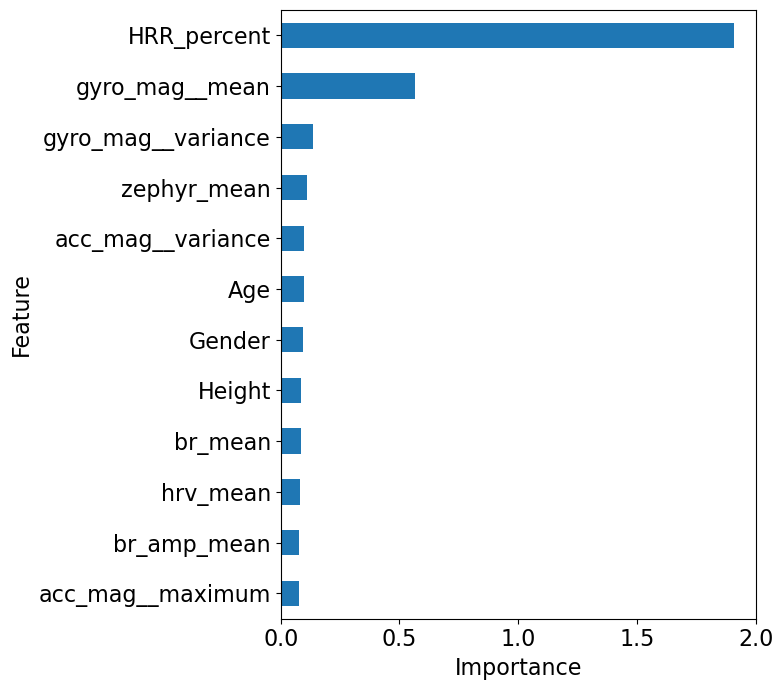

In [125]:
lime_xg = LIMEAnalyzer(experiments["random_forest"])

lime_xg.plot_global_importance(
    "random_forest",
    "ALL",
    top_n = 12,
    save_path="LIME_Random_ALL.png"
)

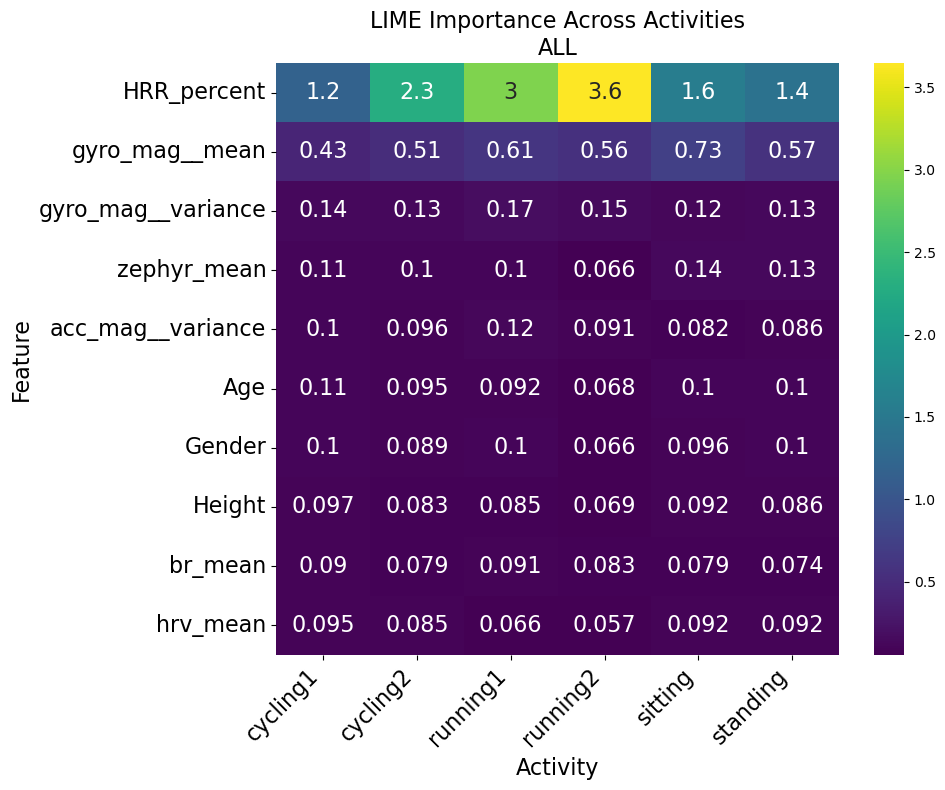

In [139]:
lime_rf.plot_activity_heatmap(
    model_type="random_forest",
    version="ALL",
        top_n = 10,
    save_path="ALL_ran_Mean.png"
)

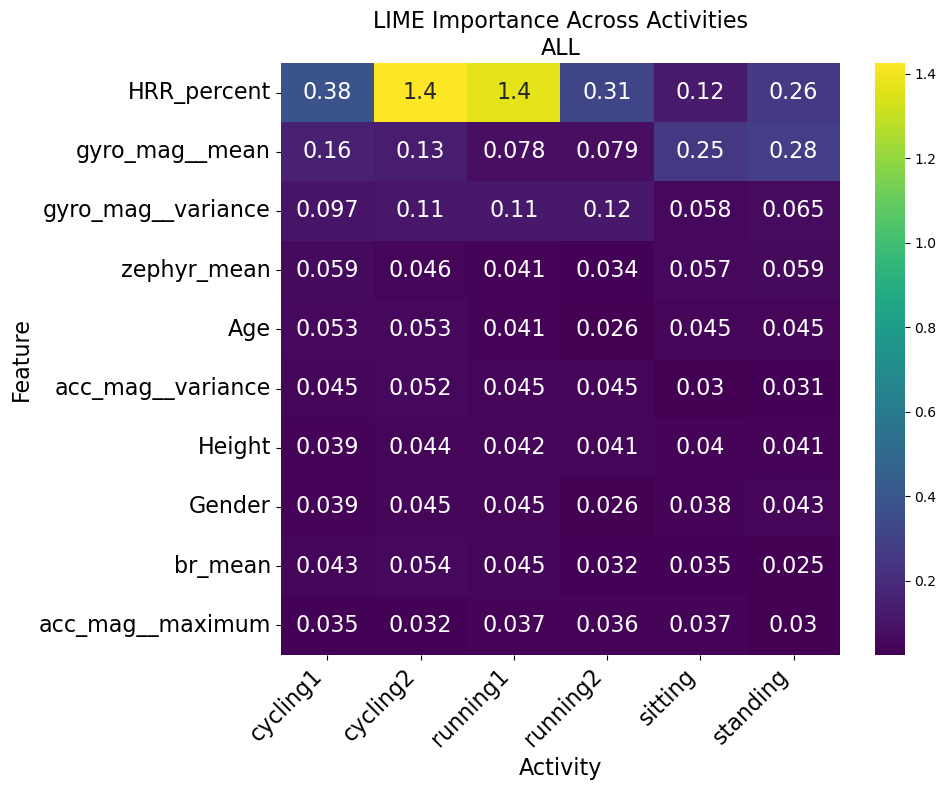

In [140]:
lime_rf12.plot_activity_sd_heatmap(
    model_type="random_forest",
    version="ALL",
            top_n = 10,
    save_path="ALL_ran_Std.png"
)

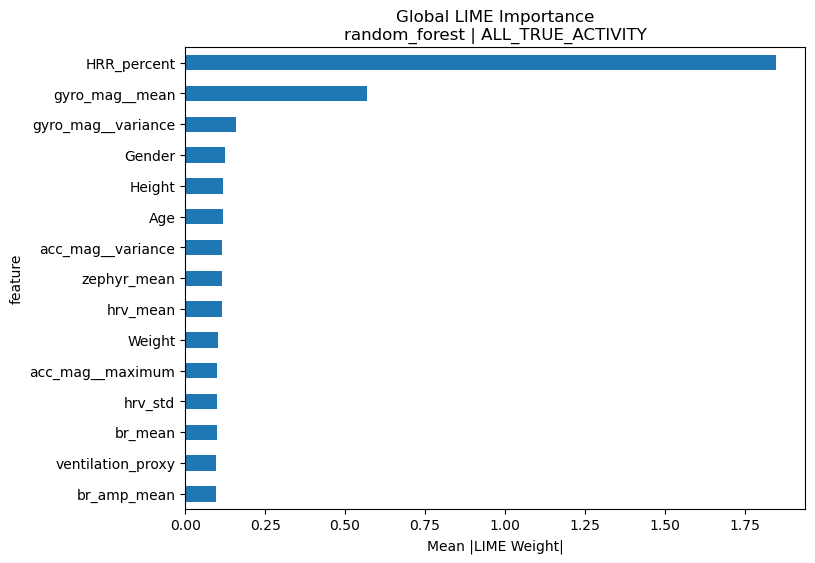

In [199]:
lime_rf11 = LIMEAnalyzer(experiments["random_forest"])

lime_rf11.plot_global_importance(
    "random_forest",
    "ALL_TRUE_ACTIVITY"
)

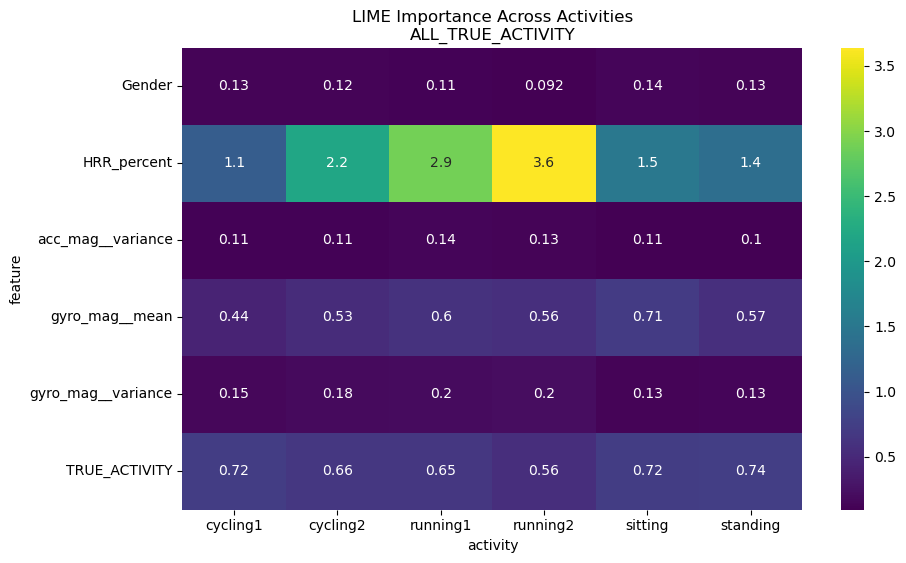

In [201]:
lime_rf11.plot_activity_heatmap(
    model_type="random_forest",
    version="ALL_TRUE_ACTIVITY"
)

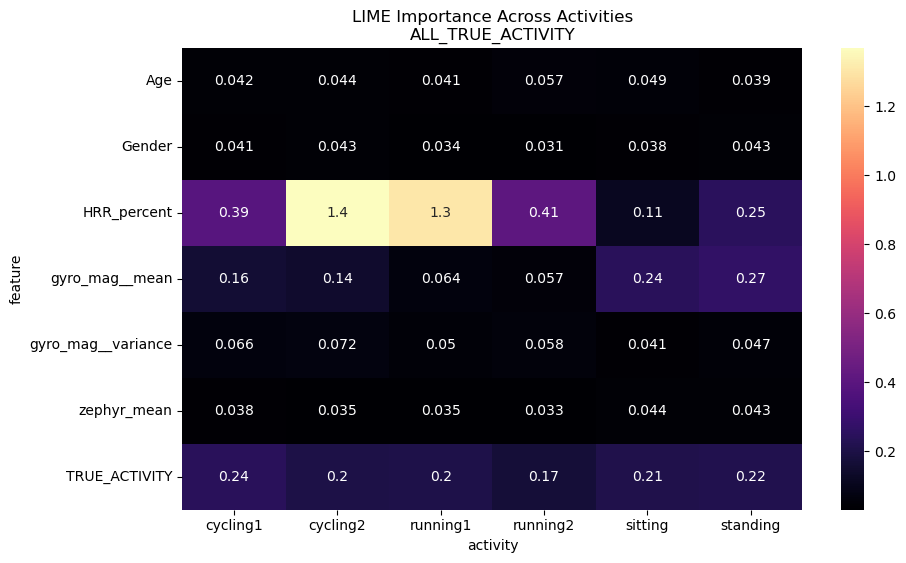

In [203]:
lime_rf11.plot_activity_sd_heatmap(
    model_type="random_forest",
    version="ALL_TRUE_ACTIVITY"
)


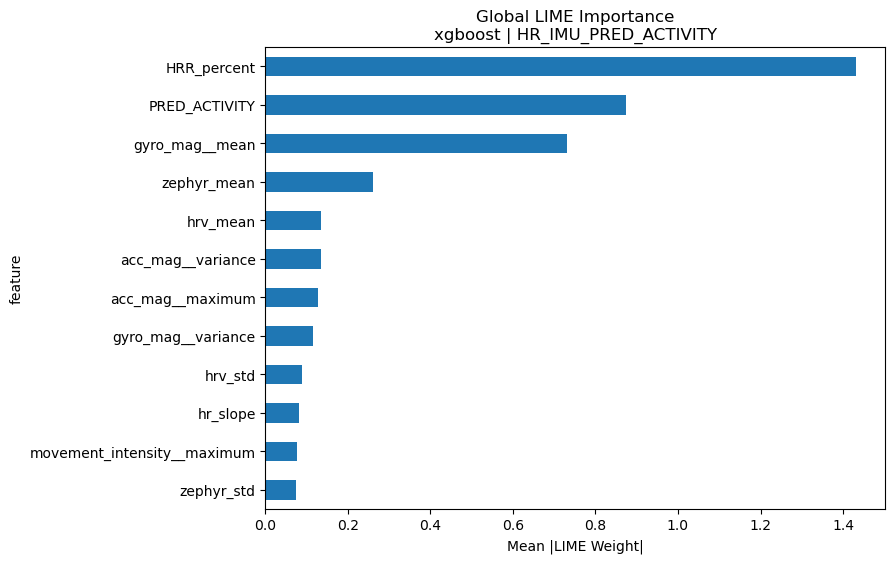

In [94]:
lime_xg1 = LIMEAnalyzer(experiments["xgboost"])

lime_xg1.plot_global_importance(
    "xgboost",
    "HR_IMU_PRED_ACTIVITY"
)

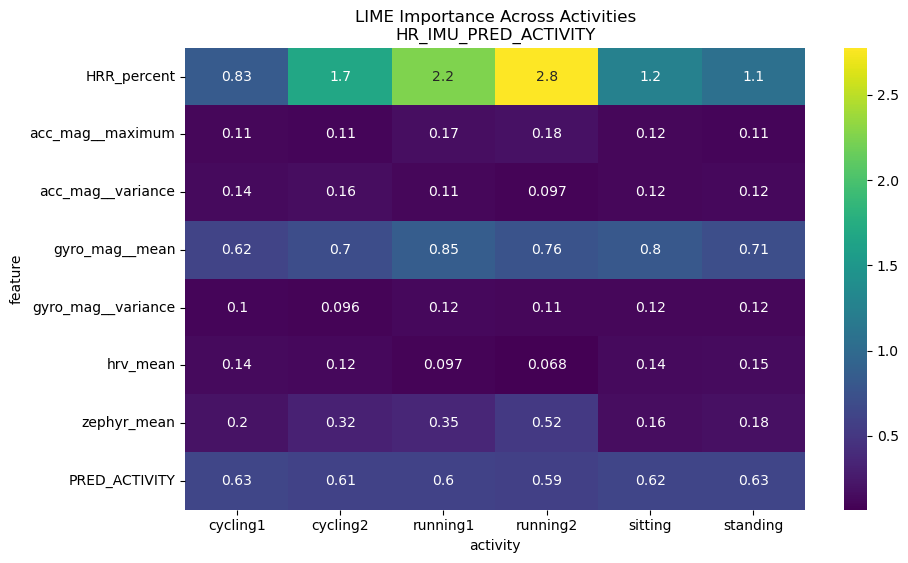

In [95]:
lime_xg1.plot_activity_heatmap(
    model_type="xgboost",
    version="HR_IMU_PRED_ACTIVITY"
)

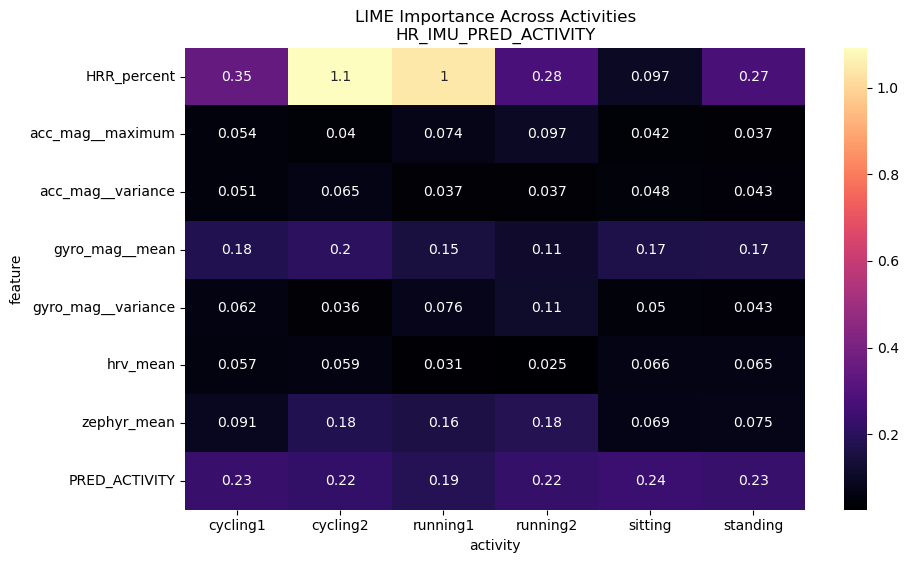

In [97]:
lime_xg1.plot_activity_sd_heatmap(
    model_type="xgboost",
    version="HR_IMU_PRED_ACTIVITY"
)